In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import data
from models.scoreMLP import ScoreMLP, score, v, v_jvp, full_jacobian
import train as T

%matplotlib inline

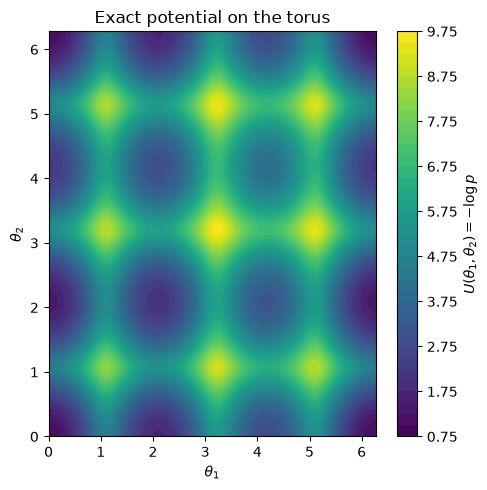

In [19]:
N = 2000

th = np.linspace(0, 2*np.pi, N, endpoint=False)
TH1, TH2 = np.meshgrid(th, th, indexing="ij")
TH1, TH2 = TH1.ravel(), TH2.ravel()
angles_grid = np.column_stack([TH1, TH2])

U = data.potential(angles_grid, data.KAPPA).reshape(N, N)

fig, ax = plt.subplots(figsize=(5, 5))
c = ax.contourf(th, th, U.T, levels=40, cmap='viridis')
plt.colorbar(c, ax=ax, label=r'$U(\theta_1,\theta_2) = -\log p$')
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_title('Exact potential on the torus')
plt.tight_layout()
plt.show()

epoch 0, step 0/98000: loss=4.0475
epoch 2, step 500/98000: loss=3.1841
epoch 5, step 1000/98000: loss=3.0685
epoch 7, step 1500/98000: loss=2.8643
epoch 10, step 2000/98000: loss=2.7131
epoch 12, step 2500/98000: loss=2.8387
epoch 15, step 3000/98000: loss=2.5666
epoch 17, step 3500/98000: loss=2.5342
epoch 20, step 4000/98000: loss=2.6468
epoch 22, step 4500/98000: loss=2.5236
epoch 25, step 5000/98000: loss=2.6386
epoch 28, step 5500/98000: loss=2.6740
epoch 30, step 6000/98000: loss=2.5599
epoch 33, step 6500/98000: loss=2.5527
epoch 35, step 7000/98000: loss=2.3847
epoch 38, step 7500/98000: loss=2.6867
epoch 40, step 8000/98000: loss=2.4454
epoch 43, step 8500/98000: loss=2.7913
epoch 45, step 9000/98000: loss=2.5346
epoch 48, step 9500/98000: loss=2.4446
epoch 51, step 10000/98000: loss=2.6441
epoch 53, step 10500/98000: loss=2.3684
epoch 56, step 11000/98000: loss=2.4793
epoch 58, step 11500/98000: loss=2.2997
epoch 61, step 12000/98000: loss=2.5866
epoch 63, step 12500/98000: 

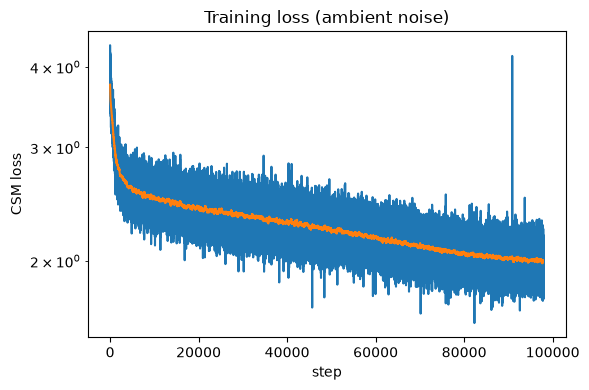

In [22]:
from torch.utils.data import DataLoader
from data import TorusDataset

ds = TorusDataset(n=100_000, seed=0)
loader = DataLoader(ds, batch_size=T.BATCH_SIZE, shuffle=True)

model_ambient, losses_ambient = T.train(loader, dim=4, n_epochs=500, seed=1, log_every=500)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses_ambient)
ax.set_xlabel('step')
ax.set_ylabel('CSM loss')
ax.set_yscale('log')
ax.set_title('Training loss (ambient noise)')

window = 200
smoothed = np.convolve(losses_ambient, np.ones(window)/window, mode='valid')
ax.plot(smoothed)
plt.tight_layout()
plt.show()


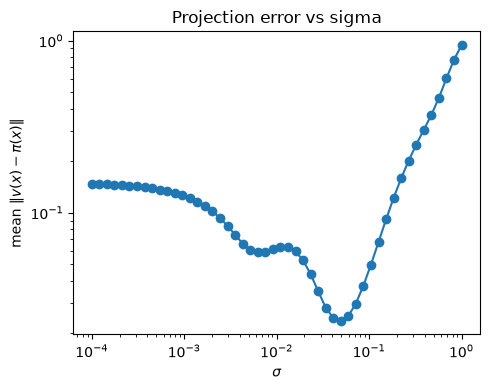

In [21]:
x_tub_np, amps = data.sample_tubular(n=100000, tau=0.3, seed=2)
x_tub = torch.tensor(x_tub_np, dtype=torch.float32)
sigmas_test = torch.logspace(-4, 0, steps=50)

errors = []
for sig in sigmas_test:
    sigma_batch = torch.full((x_tub.shape[0],), sig.item())
    v_pred = v(x_tub, sigma_batch, model_ambient)
    pi_exact = torch.tensor(data.project(x_tub_np), dtype=torch.float32)

    error = (v_pred - pi_exact).norm(dim=-1)
    errors.append(error.mean().item())


fig, ax = plt.subplots(figsize=(5,4))
ax.plot(sigmas_test.numpy(), errors, 'o-')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\sigma$'); ax.set_ylabel(r'mean $\|v(x)-\pi(x)\|$')
ax.set_title('Projection error vs sigma')
plt.tight_layout(); plt.show()

epoch 0, step 0/9800: loss=26.9551
epoch 0, step 50/9800: loss=27.0292
epoch 1, step 100/9800: loss=26.8668
epoch 1, step 150/9800: loss=26.6126
epoch 2, step 200/9800: loss=25.6113
epoch 2, step 250/9800: loss=25.7617
epoch 3, step 300/9800: loss=25.7472
epoch 3, step 350/9800: loss=25.2529
epoch 4, step 400/9800: loss=25.1963
epoch 4, step 450/9800: loss=24.8752
epoch 5, step 500/9800: loss=24.3438
epoch 5, step 550/9800: loss=24.7956
epoch 6, step 600/9800: loss=24.9967
epoch 6, step 650/9800: loss=25.1471
epoch 7, step 700/9800: loss=24.2997
epoch 7, step 750/9800: loss=24.4486
epoch 8, step 800/9800: loss=24.4146
epoch 8, step 850/9800: loss=24.0176
epoch 9, step 900/9800: loss=23.6430
epoch 9, step 950/9800: loss=24.6452
epoch 10, step 1000/9800: loss=24.1405
epoch 10, step 1050/9800: loss=23.4124
epoch 11, step 1100/9800: loss=23.9820
epoch 11, step 1150/9800: loss=23.6950
epoch 12, step 1200/9800: loss=23.2380
epoch 12, step 1250/9800: loss=23.3709
epoch 13, step 1300/9800: los

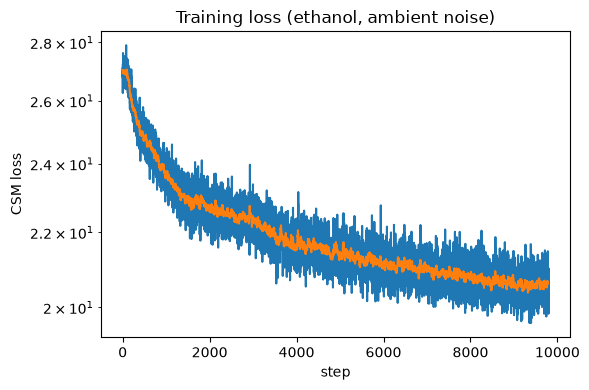

In [ ]:
from torch.utils.data import DataLoader
from ethanol_data import EthanolDataset
import train as T

eth_ds = EthanolDataset(n_frames=50000)
loader = DataLoader(eth_ds, batch_size=T.BATCH_SIZE, shuffle=True)

model_eth, losses_eth = T.train(loader, dim=27, n_epochs=1500, seed=0, log_every=50)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses_eth)
ax.set_xlabel('step')
ax.set_ylabel('CSM loss')
ax.set_yscale('log')
ax.set_title('Training loss (ethanol, ambient noise)')

window = 20
smoothed = np.convolve(losses_eth, np.ones(window)/window, mode='valid')
ax.plot(smoothed)
plt.tight_layout()
plt.show()

In [5]:
x_eth = eth_ds.points[:5].clone()
sigma_test = torch.tensor([0.05])

for i in range(x_eth.shape[0]):
    x_i = x_eth[i:i+1]
    jac = full_jacobian(x_i, sigma_test, model_eth)
    eigvals = torch.linalg.eigvals(jac[0]).real
    eigvals_sorted = torch.sort(eigvals, descending=True).values
    print(f"point {i}: top 5 eigenvalues = {eigvals_sorted[:5].tolist()}")
    print(f"         bottom 5 eigenvalues = {eigvals_sorted[-5:].tolist()}")

point 0: top 5 eigenvalues = [1.0000009536743164, 1.0000005960464478, 1.0000004768371582, 0.9999998211860657, 0.9999996423721313]
         bottom 5 eigenvalues = [0.9999954104423523, 0.9999948740005493, 0.9999939203262329, 0.9999912977218628, 0.9999912977218628]
point 1: top 5 eigenvalues = [1.0000005960464478, 1.0000005960464478, 1.0000001192092896, 1.0, 1.0]
         bottom 5 eigenvalues = [0.9999960660934448, 0.9999946355819702, 0.9999946355819702, 0.9999910593032837, 0.9999910593032837]
point 2: top 5 eigenvalues = [1.0000001192092896, 0.9999999403953552, 0.9999998211860657, 0.9999996423721313, 0.9999996423721313]
         bottom 5 eigenvalues = [0.9999954700469971, 0.9999954104423523, 0.999994158744812, 0.9999909400939941, 0.9999909400939941]
point 3: top 5 eigenvalues = [1.0, 0.9999999403953552, 0.9999997615814209, 0.9999997615814209, 0.9999995231628418]
         bottom 5 eigenvalues = [0.9999948143959045, 0.9999943971633911, 0.9999943971633911, 0.9999910593032837, 0.999991059303